# Supplementary Figure S41: LR-complex aggregation

Compare minimum and geometric-mean aggregation of multi-subunit LR expression. Calculate score correlations and top-100 LR-pair overlap for S41.


## Before you start

Follow the [source installation](../../installation.md), then run these cells in order. The numerical inputs are included with the code. The notebook saves new figures and their calculation tables.

To generate these inputs from fitted models, see the [calculation guide](../../reference/figure_sources/lr-complex.md).


## Imports and configuration

In [1]:
import os
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results import load_lr_complex_aggregation_results
from CytoBridge.results.lr_complex_aggregation import (
    summarize_lr_complex_aggregation,
    write_lr_complex_aggregation_tables,
)

output_dir = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")) / "outputs" / "lr_complex_aggregation"
output_dir.mkdir(parents=True, exist_ok=True)

## Load processed results

In [2]:
import os
results_dir = os.environ.get("CYTOBRIDGE_LR_COMPLEX_RESULTS")
results = load_lr_complex_aggregation_results(results_dir, top_n=100)
display(
    results.paired_scores[
        ["dataset", "time", "pair", "score_min", "score_geometric_mean", "is_multisubunit"]
    ].head()
)

,dataset,time,pair,score_min,score_geometric_mean,is_multisubunit
0,zebrafish,0.0,adcyap1a_adcyap1r1a,0.0,0.0,False
1,zebrafish,0.0,adipoqb_adipor1a,0.0,0.0,False
2,zebrafish,0.0,adipoqb_adipor1b,0.0,0.0,False
3,zebrafish,0.0,adipoqb_adipor2,0.0,0.0,False
4,zebrafish,0.0,adma_calcr,0.0,0.0,False


## Recalculate panel data

Spearman correlation is calculated over all pair-time rows and separately at each time. Panel c selects the top 100 LR pairs for each aggregation method at each time and calculates their Jaccard overlap. Pair names break score ties. The plotting calculation writes these values to `tables/S41_top100_jaccard.csv`.

In [3]:
per_time, dataset_summary = summarize_lr_complex_aggregation(results.paired_scores, top_n=100)
display(dataset_summary)
display(per_time.loc[per_time["scope"].eq("all_scored_pairs")].head(12))

,dataset,n_scored_pairs,n_multisubunit_pairs,pooled_spearman,min_per_time_spearman,min_top100_jaccard
0,Zebrafish,1832,973,0.998558,0.954636,0.834862
1,MOSTA,1757,887,0.984745,0.982595,0.785714
2,ARISTA,531,293,0.960106,0.950453,0.769912
3,Chicken Heart,745,386,0.977109,0.957120,0.612903


,dataset,time,normalized_time,scope,n_pairs,spearman,top_n,top_overlap_n,top_jaccard
0,Zebrafish,0.0,0.000000,all_scored_pairs,1832,0.999994,100,100,1.000000
2,Zebrafish,0.5,0.125000,all_scored_pairs,1832,0.960729,100,96,0.923077
4,Zebrafish,1.0,0.250000,all_scored_pairs,1832,NaN,100,100,1.000000
6,Zebrafish,1.5,0.375000,all_scored_pairs,1832,NaN,100,100,1.000000
8,Zebrafish,2.0,0.500000,all_scored_pairs,1832,0.999921,100,91,0.834862
10,Zebrafish,2.5,0.625000,all_scored_pairs,1832,0.954636,100,95,0.904762
12,Zebrafish,3.0,0.750000,all_scored_pairs,1832,0.993753,100,97,0.941748
14,Zebrafish,3.5,0.875000,all_scored_pairs,1832,0.956563,100,97,0.941748
16,Zebrafish,4.0,1.000000,all_scored_pairs,1832,0.976764,100,93,0.869159
18,MOSTA,0.0,0.000000,all_scored_pairs,1757,0.982595,100,88,0.785714


## Render and save the figure

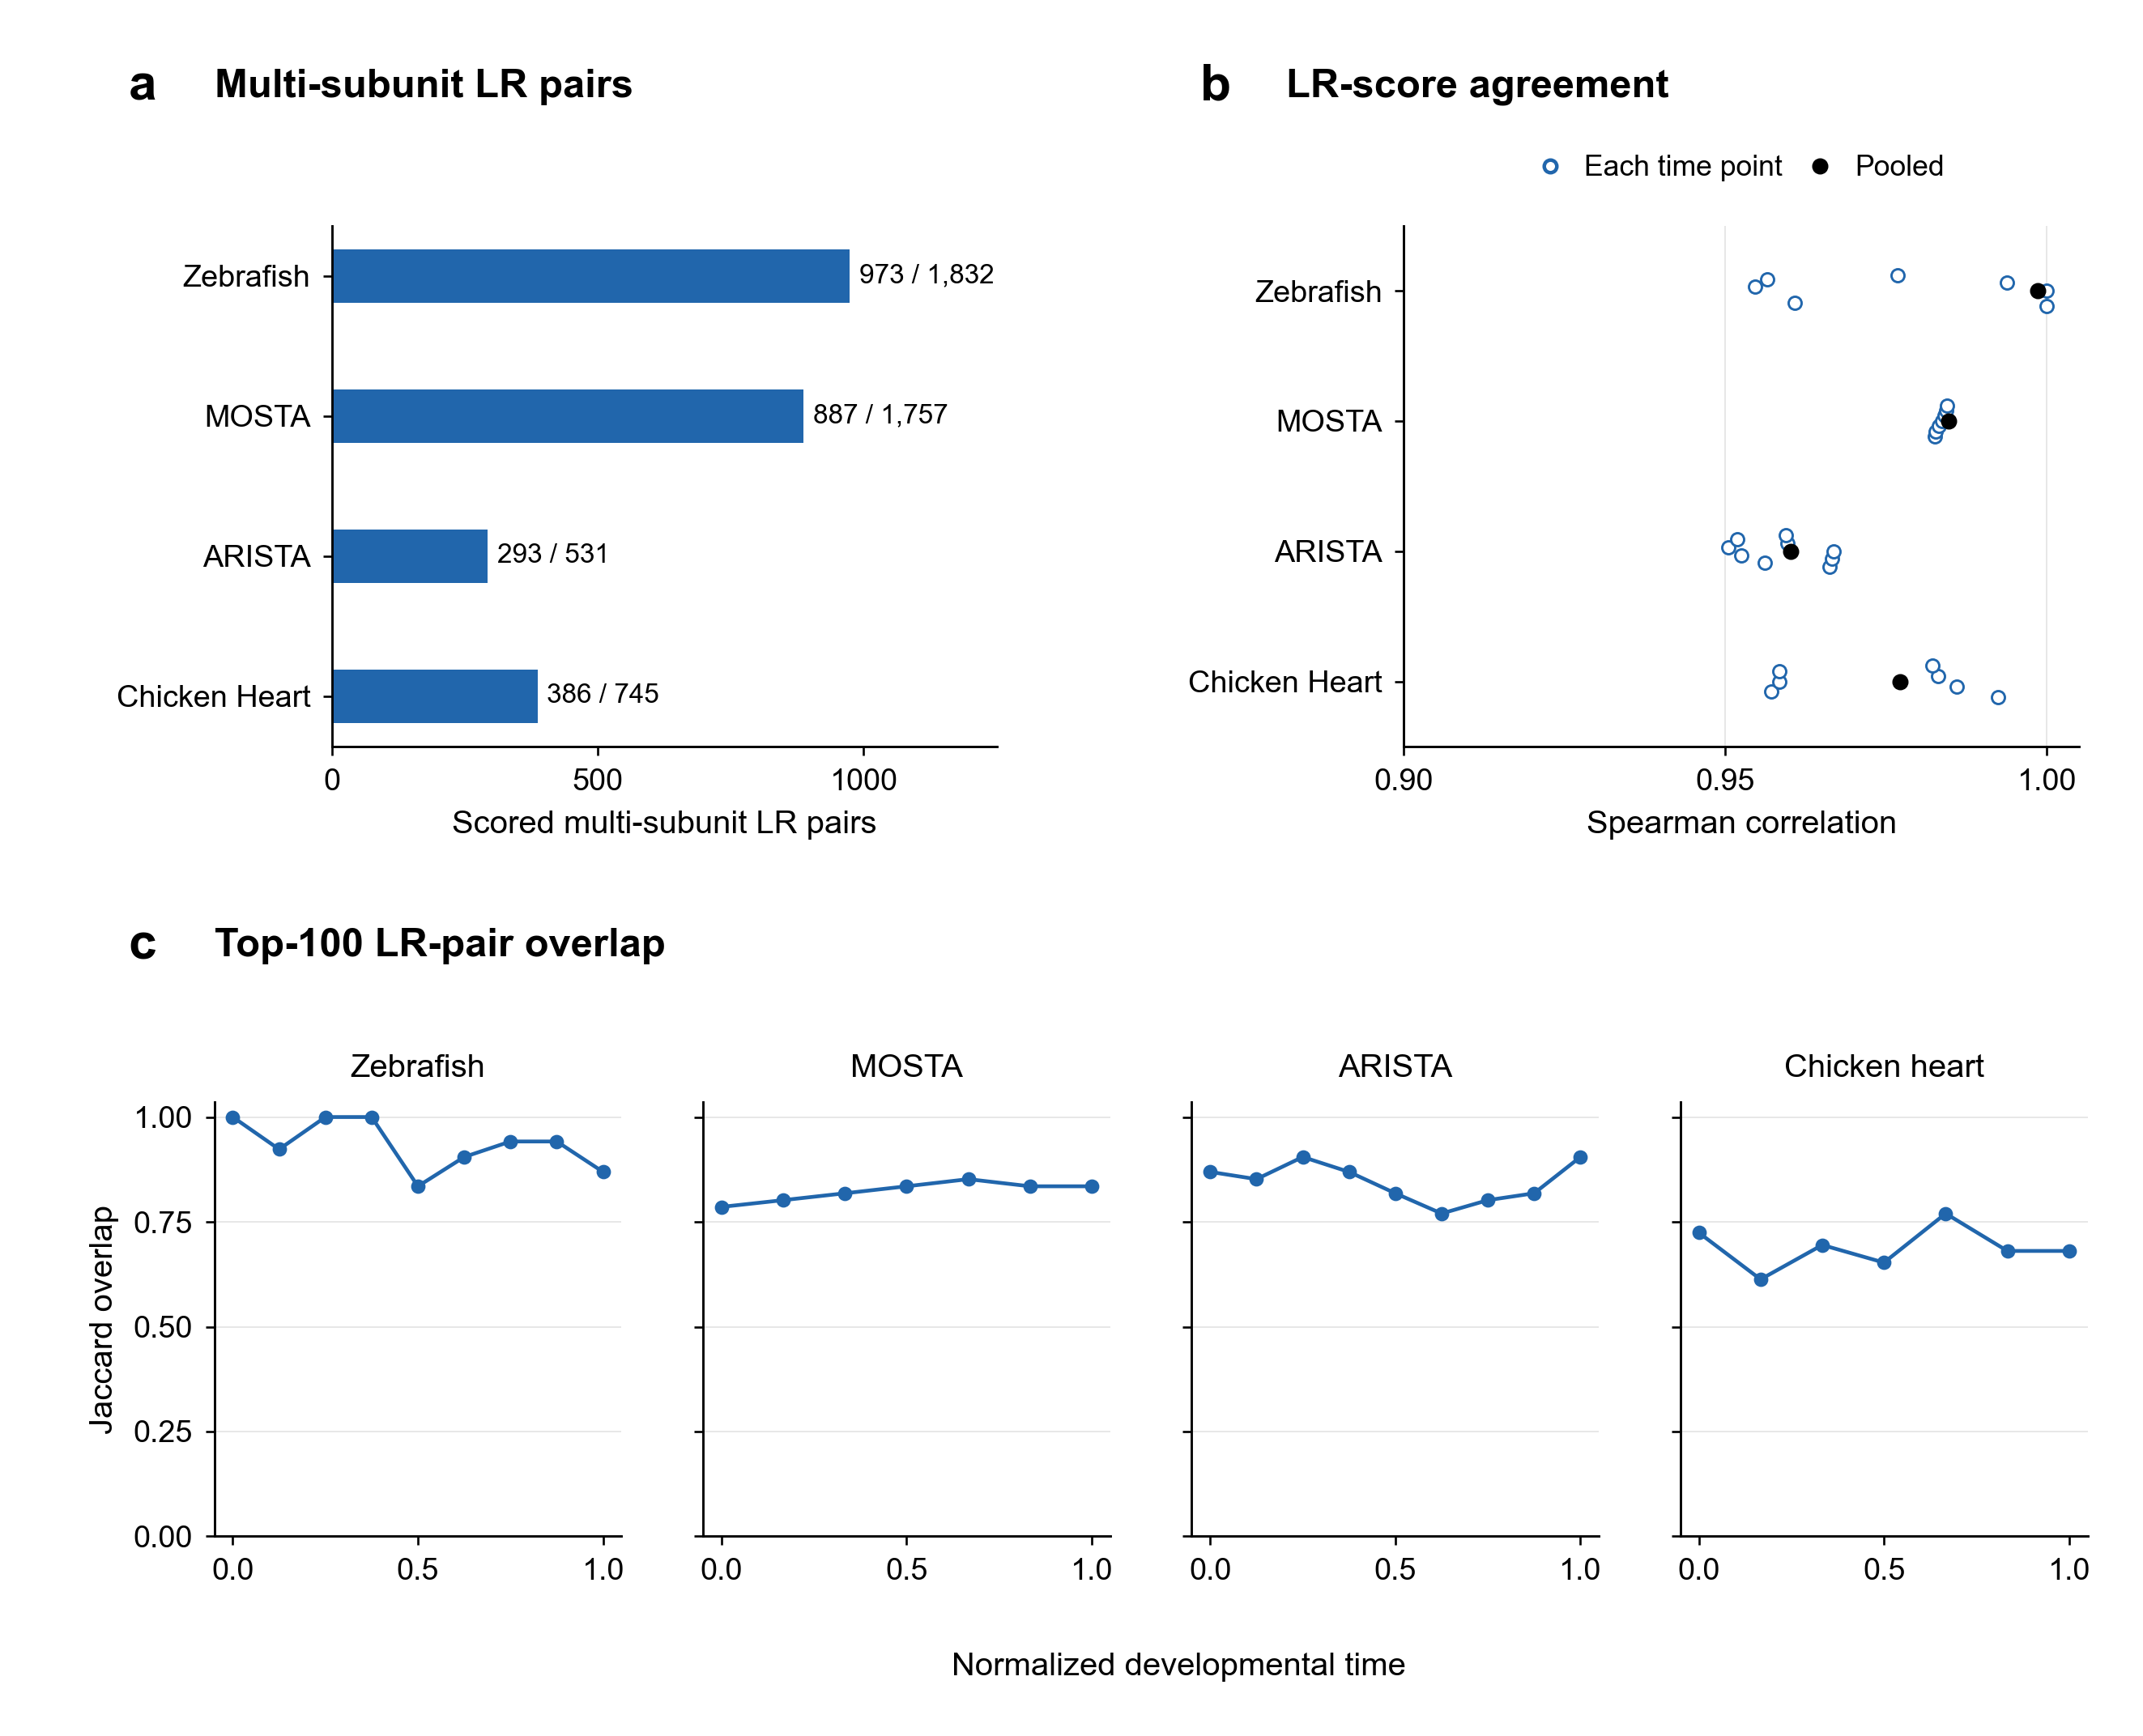

In [4]:
table_paths = write_lr_complex_aggregation_tables(results, output_dir)
from reproduction.paper_figures import draw_supplementary
pdf_path, png_path = draw_supplementary([41], output_dir, results_dir=results.source_dir)["s41"]
display(Image(filename=str(png_path), width=700))

## Check outputs

In [5]:
{
    "pair_time_rows": len(results.paired_scores),
    "per_time_rows": len(per_time),
    "dataset_rows": len(dataset_summary),
    "tables": {name: path.is_file() for name, path in table_paths.items()},
    "pdf": pdf_path.is_file(),
    "png": png_path.is_file(),
}

{'pair_time_rows': 38781,
 'per_time_rows': 64,
 'dataset_rows': 4,
 'tables': {'per_time': True, 'dataset_summary': True},
 'pdf': True,
 'png': True}

## Use results from another run

The [LR aggregation calculation](../../reference/figure_sources/lr-complex.md) starts from a completed model analysis and calculates the paired scores used here.